In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

In [7]:

iris = datasets.load_iris()
X = iris.data
y = iris.target


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

In [11]:
def calculate_and_plot_metrics(X_train, y_train, X_test, y_test, title):

    # Train Model
    mlp.fit(X_train, y_train)

    # Prediction
    y_pred = mlp.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=iris.target_names
    )

    disp.plot(
        cmap='viridis',
        values_format='d',
        ax=axes[0]
    )

    axes[0].set_title("Confusion Matrix")

    # Loss Curve
    axes[1].plot(mlp.loss_curve_)
    axes[1].set_title("MLP Loss Curve")
    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("Loss")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    # 10-Fold Cross Validation
    cv_scores = cross_val_score(
        mlp,
        X_train,
        y_train,
        cv=10,
        scoring='accuracy'
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        cv_scores,
        y_pred
    )

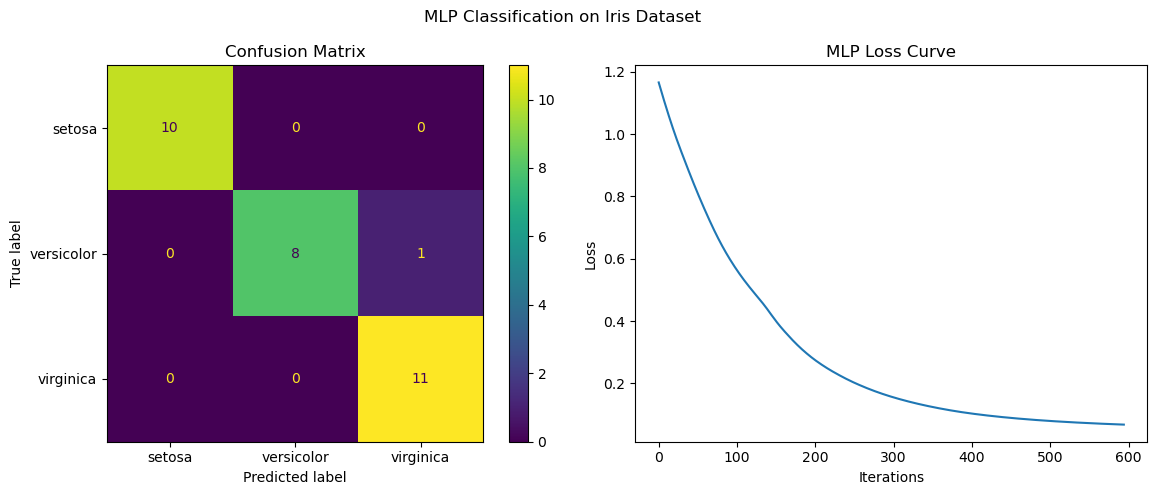

In [12]:
accuracy, precision, recall, f1, cv_scores, y_pred = calculate_and_plot_metrics(
    X_train,
    y_train,
    X_test,
    y_test,
    "MLP Classification on Iris Dataset"
)

In [13]:
print("========== RESULTS ==========\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n10-Fold Cross Validation Accuracy:")
print(cv_scores)
print(f"Average Accuracy: {np.mean(cv_scores):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

========== RESULTS ==========

Accuracy  : 0.9667
Precision : 0.9694
Recall    : 0.9667
F1 Score  : 0.9664

10-Fold Cross Validation Accuracy:
[0.91666667 1.         1.         1.         0.66666667 0.83333333
 1.         1.         1.         0.91666667]
Average Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

